<a href="https://colab.research.google.com/github/zainaahamed-work/Employee-Attrition-Analytics-XAI/blob/main/Employee_Attrition_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
# Mount Google Drive to access the dataset stored in the project folder
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [22]:
# Verify the dataset file exists in the mounted Drive folder
!ls "/content/drive/MyDrive/Employee_Attrition_Project"

WA_Fn-UseC_-HR-Employee-Attrition.csv


In [23]:
# Import pandas for loading and analysing the dataset
import pandas as pd

# Load the IBM HR Analytics Employee Attrition dataset
df = pd.read_csv('/content/drive/MyDrive/Employee_Attrition_Project/WA_Fn-UseC_-HR-Employee-Attrition.csv')

# Preview the first 5 rows to confirm the data loaded correctly
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [24]:
# Check the dataset's dimensions: number of employees and number of attributes
df.shape

(1470, 35)

In [25]:
# Review data types and non-null counts for every column
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [26]:
# Generate summary statistics for all numeric columns
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [27]:
# Confirm there are no missing values across the dataset
df.isnull().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


In [28]:
# Count how many employees left versus stayed
df['Attrition'].value_counts()

,count
Attrition,
No,1233
Yes,237


In [29]:
# Express the attrition split as percentages to highlight the class imbalance
df['Attrition'].value_counts(normalize=True) * 100

,proportion
Attrition,
No,83.877551
Yes,16.122449


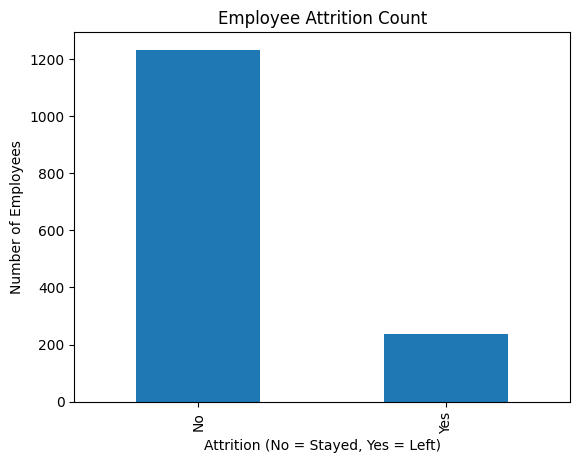

In [30]:
# Import matplotlib for visualising the attrition distribution
import matplotlib.pyplot as plt

# Store the attrition counts to plot
attrition_counts = df['Attrition'].value_counts()

# Plot attrition counts as a bar chart
attrition_counts.plot(kind='bar')

# Label the chart for clarity
plt.title('Employee Attrition Count')
plt.xlabel('Attrition (No = Stayed, Yes = Left)')
plt.ylabel('Number of Employees')

# Display the chart
plt.show()

In [31]:
# Remove columns with no analytical value: EmployeeCount, Over18, and StandardHours
# are constant across all records, and EmployeeNumber is an arbitrary identifier
df = df.drop(columns=['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours'])

# Confirm the columns were removed
df.shape

(1470, 31)

In [32]:
# Encode the target variable: Yes (left) becomes 1, No (stayed) becomes 0
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

# Verify the encoding
df['Attrition'].value_counts()

,count
Attrition,
0,1233
1,237


In [33]:
# Import the tool used to convert categorical text into numeric labels
from sklearn.preprocessing import LabelEncoder

# Reuse a single encoder instance across all categorical columns
le = LabelEncoder()

# Columns requiring conversion from text categories to numeric labels
categorical_columns = ['Department', 'JobRole', 'Gender', 'MaritalStatus', 'OverTime', 'BusinessTravel', 'EducationField']

# Encode each column and record the category-to-number mapping for reference
for column in categorical_columns:
    df[column] = le.fit_transform(df[column])
    print(f"{column} -> {list(le.classes_)}")

Department -> ['Human Resources', 'Research & Development', 'Sales']
JobRole -> ['Healthcare Representative', 'Human Resources', 'Laboratory Technician', 'Manager', 'Manufacturing Director', 'Research Director', 'Research Scientist', 'Sales Executive', 'Sales Representative']
Gender -> ['Female', 'Male']
MaritalStatus -> ['Divorced', 'Married', 'Single']
OverTime -> ['No', 'Yes']
BusinessTravel -> ['Non-Travel', 'Travel_Frequently', 'Travel_Rarely']
EducationField -> ['Human Resources', 'Life Sciences', 'Marketing', 'Medical', 'Other', 'Technical Degree']


In [34]:
# Import the tool used to scale numeric features onto a common 0-1 range
from sklearn.preprocessing import MinMaxScaler

# Create the scaler instance
scaler = MinMaxScaler()

# Every column is now numeric; the target is excluded since it should not be scaled
feature_columns = df.columns.drop('Attrition')

# Scale all feature columns to the 0-1 range
df[feature_columns] = scaler.fit_transform(df[feature_columns])

# Preview the result
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,0.547619,1,1.0,0.715820,1.0,0.000000,0.25,0.2,0.333333,0.0,...,0.0,0.000000,0.000000,0.200,0.0,0.000000,0.15,0.222222,0.000000,0.294118
1,0.738095,0,0.5,0.126700,0.5,0.250000,0.00,0.2,0.666667,1.0,...,1.0,1.000000,0.333333,0.250,0.5,0.666667,0.25,0.388889,0.066667,0.411765
2,0.452381,1,1.0,0.909807,0.5,0.035714,0.25,0.8,1.000000,1.0,...,0.0,0.333333,0.000000,0.175,0.5,0.666667,0.00,0.000000,0.000000,0.000000
3,0.357143,0,0.5,0.923407,0.5,0.071429,0.75,0.2,1.000000,0.0,...,0.0,0.666667,0.000000,0.200,0.5,0.666667,0.20,0.388889,0.200000,0.000000
4,0.214286,0,1.0,0.350036,0.5,0.035714,0.00,0.6,0.000000,1.0,...,0.0,1.000000,0.333333,0.150,0.5,0.666667,0.05,0.111111,0.133333,0.117647


In [36]:
# Save the cleaned and prepared dataset for use in later phases
df.to_csv('/content/drive/MyDrive/Employee_Attrition_Project/HR_Attrition_Cleaned.csv', index=False)